# 02 — Zero-Shot Document Classification: 7 Model Comparison
**Group 1 – Invoices | Step 2**

Comparing **7 open-source models** on zero-shot document classification (RVL-CDIP, 16 classes):

| # | Model | Company | Approach |
|---|-------|---------|----------|
| 1 | **Qwen2-VL-7B** | Alibaba | Strong at reading text in images |
| 2 | **Qwen2.5-VL-3B** | Alibaba | Lightweight version of Qwen2.5-VL |
| 3 | **CLIP ViT-B/32** | OpenAI | Contrastive image-text similarity |
| 4 | **SmolVLM-500M** | HuggingFace | Lightweight instruction-tuned VLM |
| 5 | **PaliGemma2-3B** | Google | Compact multimodal LM |
| 6 | **DiT-large** | Microsoft | Fine-tuned on RVL-CDIP (supervised) |

Each model is evaluated on the same balanced dataset (100 examples × 16 classes = 1600 total).
Models are loaded one at a time and unloaded after evaluation to fit on a single GPU.

> **Checkpoint system**: each model's results are saved to disk after evaluation.
> Re-running the notebook will **skip** already-completed models automatically.

## 0 — Environment setup (Colab / Kaggle / Local)

In [1]:
import os

In [2]:
def _is_kaggle():
    return os.path.exists('/kaggle/working')

def _is_colab():
    try:
        import google.colab  # noqa: F401
        return not _is_kaggle()
    except ImportError:
        return False

PLATFORM = 'kaggle' if _is_kaggle() else ('colab' if _is_colab() else 'local')
print(PLATFORM)

kaggle


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# COLAB SETUP
# ══════════════════════════════════════════════════════════════════════════
if PLATFORM == 'colab':
    USE_DRIVE = True  # ← False per salvare in /content/outputs senza montare Drive

    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_PROJECT_DIR = '/content/drive/MyDrive/NLP_Invoices'
        OUTPUT_DIR = os.path.join(DRIVE_PROJECT_DIR, 'outputs')
    else:
        OUTPUT_DIR = '/content/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f'Output → {OUTPUT_DIR}')

    from huggingface_hub import get_token
    HF_TOKEN = get_token()
    if not HF_TOKEN:
        try:
            from google.colab import userdata
            HF_TOKEN = userdata.get('HF_TOKEN')
        except Exception:
            pass
    if not HF_TOKEN:
        raise ValueError('HF_TOKEN non trovato.')
    from huggingface_hub import login
    login(token=HF_TOKEN)
    print('✅ Colab ready')

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# KAGGLE SETUP
# ══════════════════════════════════════════════════════════════════════════
if PLATFORM == 'kaggle':
    OUTPUT_DIR = '/kaggle/working/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    HF_TOKEN = None
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret('HF_TOKEN')
        print('HF_TOKEN letto dai Kaggle Secrets')
    except Exception as _e:
        print(f'Kaggle Secrets non disponibili: {_e}')

    KAGGLE_TOKEN_FILE = '/kaggle/input/MY-HF-TOKEN-DATASET/hf_token.txt'
    if not HF_TOKEN and os.path.isfile(KAGGLE_TOKEN_FILE):
        with open(KAGGLE_TOKEN_FILE) as _f:
            HF_TOKEN = _f.read().strip()

    if not HF_TOKEN:
        raise ValueError('HF_TOKEN non trovato.')

    from huggingface_hub import login
    login(token=HF_TOKEN)
    print(f'✅ Kaggle ready. Output → {OUTPUT_DIR}')

HF_TOKEN letto dai Kaggle Secrets
✅ Kaggle ready. Output → /kaggle/working/outputs


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# LOCAL SETUP
# ══════════════════════════════════════════════════════════════════════════
if PLATFORM == 'local':
    OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    from huggingface_hub import get_token, login
    HF_TOKEN = get_token() or os.environ.get('HF_TOKEN', '')
    if not HF_TOKEN:
        raise ValueError('HF_TOKEN non trovato.')
    login(token=HF_TOKEN)
    print(f'✅ Local ready. Output → {OUTPUT_DIR}')

## 1 — Install dependencies

In [6]:
import sys
!{sys.executable} -m pip install -q einops qwen-vl-utils datasets transformers tqdm
!{sys.executable} -m pip install -q -U 'bitsandbytes>=0.46.1' accelerate
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.3 MB/s eta 0:00:00
✅ Dependencies installed


## 1 — Imports & configuration

In [7]:
import random, gc, pickle
from collections import defaultdict
from io import BytesIO

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

N_PER_CLASS   = 100
INVOICE_LABEL = 6
RANDOM_SEED   = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

LABEL_NAMES = {
    0:"advertisement", 1:"budget", 2:"email", 3:"file folder", 4:"form",
    5:"handwritten", 6:"invoice", 7:"letter", 8:"memo", 9:"news article",
    10:"presentation", 11:"questionnaire", 12:"resume", 13:"scientific publication",
    14:"scientific report", 15:"specification"
}
ALL_LABELS  = list(LABEL_NAMES.keys())
CLASS_NAMES = [LABEL_NAMES[i] for i in ALL_LABELS]

RESULTS = {}
print("Config ready.")

Device: cuda
Config ready.


## 2 — Shared helper functions

In [8]:
def parse_class(text):
    """Parse model output text into a class index. Returns -1 if unparseable."""
    t = text.strip().lower()
    for i, name in enumerate(CLASS_NAMES):
        if t == name:
            return i
    for i, name in enumerate(CLASS_NAMES):
        if name in t:
            return i
    for i, name in enumerate(CLASS_NAMES):
        if any(w in t for w in name.split() if len(w) > 3):
            return i
    return -1


def evaluate(model_name, true_labels, pred_labels, cmap="Blues"):
    """Print metrics, plot confusion matrix, store in RESULTS."""
    unparsed = sum(1 for p in pred_labels if p < 0)
    if unparsed:
        pct = 100 * unparsed / len(pred_labels)
        print(f"  ⚠ Unparsed preds: {unparsed}/{len(pred_labels)} ({pct:.1f}%)")

    acc      = accuracy_score(true_labels, pred_labels)
    f1_macro = f1_score(true_labels, pred_labels, average="macro", zero_division=0)
    inv_true = [1 if l == INVOICE_LABEL else 0 for l in true_labels]
    inv_pred = [1 if p == INVOICE_LABEL else 0 for p in pred_labels]
    inv_f1   = f1_score(inv_true, inv_pred, zero_division=0)

    print(f"\n{'─'*55}")
    print(f"  {model_name}")
    print(f"{'─'*55}")
    print(f"  Overall Accuracy : {acc:.3f}")
    print(f"  Macro F1         : {f1_macro:.3f}")
    print(f"  Invoice F1       : {inv_f1:.3f}")
    print()

    parsed_mask = [p >= 0 for p in pred_labels]
    tl_parsed = [t for t, m in zip(true_labels, parsed_mask) if m]
    pl_parsed = [p for p, m in zip(pred_labels, parsed_mask) if m]
    if tl_parsed:
        print(classification_report(tl_parsed, pl_parsed, target_names=CLASS_NAMES,
                                    labels=ALL_LABELS, digits=3, zero_division=0))

    fig, ax = plt.subplots(figsize=(14, 11))
    cm = confusion_matrix(true_labels, pred_labels, labels=ALL_LABELS)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap=cmap, xticks_rotation=45)
    ax.set_title(f"{model_name} — Confusion Matrix  (acc={acc:.3f})", fontsize=12, pad=14)
    plt.tight_layout()
    safe_name = model_name.lower().replace(" ", "_").replace("/", "_")
    path = os.path.join(OUTPUT_DIR, f"cm_{safe_name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")

    RESULTS[model_name] = {
        "preds": pred_labels, "accuracy": acc,
        "f1_macro": f1_macro, "inv_f1": inv_f1,
        "unparsed": unparsed,
    }
    return acc, f1_macro, inv_f1


def save_checkpoint():
    """Salva RESULTS e true_labels su disco dopo ogni modello."""
    ckpt_path = os.path.join(OUTPUT_DIR, "checkpoint.pkl")
    with open(ckpt_path, "wb") as f:
        pickle.dump({"RESULTS": RESULTS, "true_labels": true_labels}, f)
    print(f"  💾 Checkpoint salvato → {ckpt_path}  (modelli: {list(RESULTS.keys())})")


def load_checkpoint():
    """Carica checkpoint se esiste. Restituisce True se trovato."""
    global RESULTS, true_labels
    ckpt_path = os.path.join(OUTPUT_DIR, "checkpoint.pkl")
    if os.path.isfile(ckpt_path):
        with open(ckpt_path, "rb") as f:
            ckpt = pickle.load(f)
        RESULTS     = ckpt["RESULTS"]
        true_labels = ckpt["true_labels"]
        print(f"✅ Checkpoint caricato. Modelli già eseguiti: {list(RESULTS.keys())}")
        return True
    return False


def free_memory(*objs):
    """Delete model objects and free GPU memory."""
    for obj in objs:
        del obj
    gc.collect()
    torch.cuda.empty_cache()
    print("Memory freed.")


def to_pil(image_field):
    """Convert any HF image field format to PIL Image RGB."""
    if isinstance(image_field, Image.Image):
        return image_field.convert("RGB")
    elif isinstance(image_field, dict):
        return Image.open(BytesIO(image_field["bytes"])).convert("RGB")
    else:
        return Image.fromarray(image_field).convert("RGB")


def resize_img(img, max_size=512):
    """Riduce l'immagine mantenendo le proporzioni (per risparmiare VRAM)."""
    w, h = img.size
    if max(w, h) > max_size:
        scale = max_size / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    return img


print('Helpers ready.')

Helpers ready.


## 3 — Load balanced dataset & checkpoint
If a checkpoint exists, it is loaded and already-evaluated models are skipped.
The dataset is loaded via streaming (images are NOT kept in RAM) to save memory.

In [9]:
# ── Load checkpoint if available ──────────────────────────────────────
true_labels = None  # sarà impostato dal dataset o dal checkpoint
load_checkpoint()

# ── Streaming dataset (images are NOT loaded into RAM) ────────────────────
print(f"Streaming dataset ({N_PER_CLASS}/class × {len(ALL_LABELS)} classes)...")

stream = load_dataset("chainyo/rvl-cdip", split="test", streaming=True
         ).shuffle(seed=RANDOM_SEED, buffer_size=20_000)

balanced = defaultdict(list)
completed = set()

for example in stream:
    label = int(example["label"])
    if label in completed:
        continue
    balanced[label].append(example)
    if len(balanced[label]) >= N_PER_CLASS:
        completed.add(label)
        print(f"  ✓ {LABEL_NAMES[label]}")
    if len(completed) == len(ALL_LABELS):
        break

all_examples_meta = [ex for exs in balanced.values() for ex in exs]
random.seed(RANDOM_SEED)
random.shuffle(all_examples_meta)

# true_labels: reuse from checkpoint if already loaded, otherwise rebuild
if true_labels is None:
    true_labels = [int(ex["label"]) for ex in all_examples_meta]

print(f"\n✅ {len(all_examples_meta)} esempi pronti (immagini NON in RAM).")

Streaming dataset (100/class × 16 classes)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/119 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

  ✓ letter
  ✓ specification
  ✓ resume
  ✓ advertisement
  ✓ file folder
  ✓ presentation
  ✓ questionnaire
  ✓ invoice
  ✓ memo
  ✓ news article
  ✓ form
  ✓ handwritten
  ✓ email
  ✓ scientific publication
  ✓ budget
  ✓ scientific report

✅ 1600 esempi pronti (immagini NON in RAM).


---
## Model 1 — Qwen2-VL-7B (Alibaba)
Strong OCR-like reading of text within images — ideal for scanned documents.
Loaded with 4-bit quantization (~4 GB VRAM). Images are loaded on-the-fly to save RAM.

VRAM libera: 15.53 GB


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2-VL-7B loaded.


Qwen2-VL-7B:   0%|          | 0/1600 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


⚠️  Parse fallito: 30/1600
Done.
  ⚠ Unparsed preds: 30/1600 (1.9%)

───────────────────────────────────────────────────────
  Qwen2-VL-7B
───────────────────────────────────────────────────────
  Overall Accuracy : 0.546
  Macro F1         : 0.514
  Invoice F1       : 0.693

                        precision    recall  f1-score   support

         advertisement      0.707     0.940     0.807       100
                budget      0.895     0.340     0.493       100
                 email      1.000     0.770     0.870       100
           file folder      0.875     0.329     0.479        85
                  form      0.305     0.448     0.363        96
           handwritten      0.454     0.590     0.513       100
               invoice      0.617     0.798     0.696        99
                letter      0.323     0.600     0.420       100
                  memo      0.438     0.490     0.462       100
          news article      0.692     0.740     0.715       100
          presenta

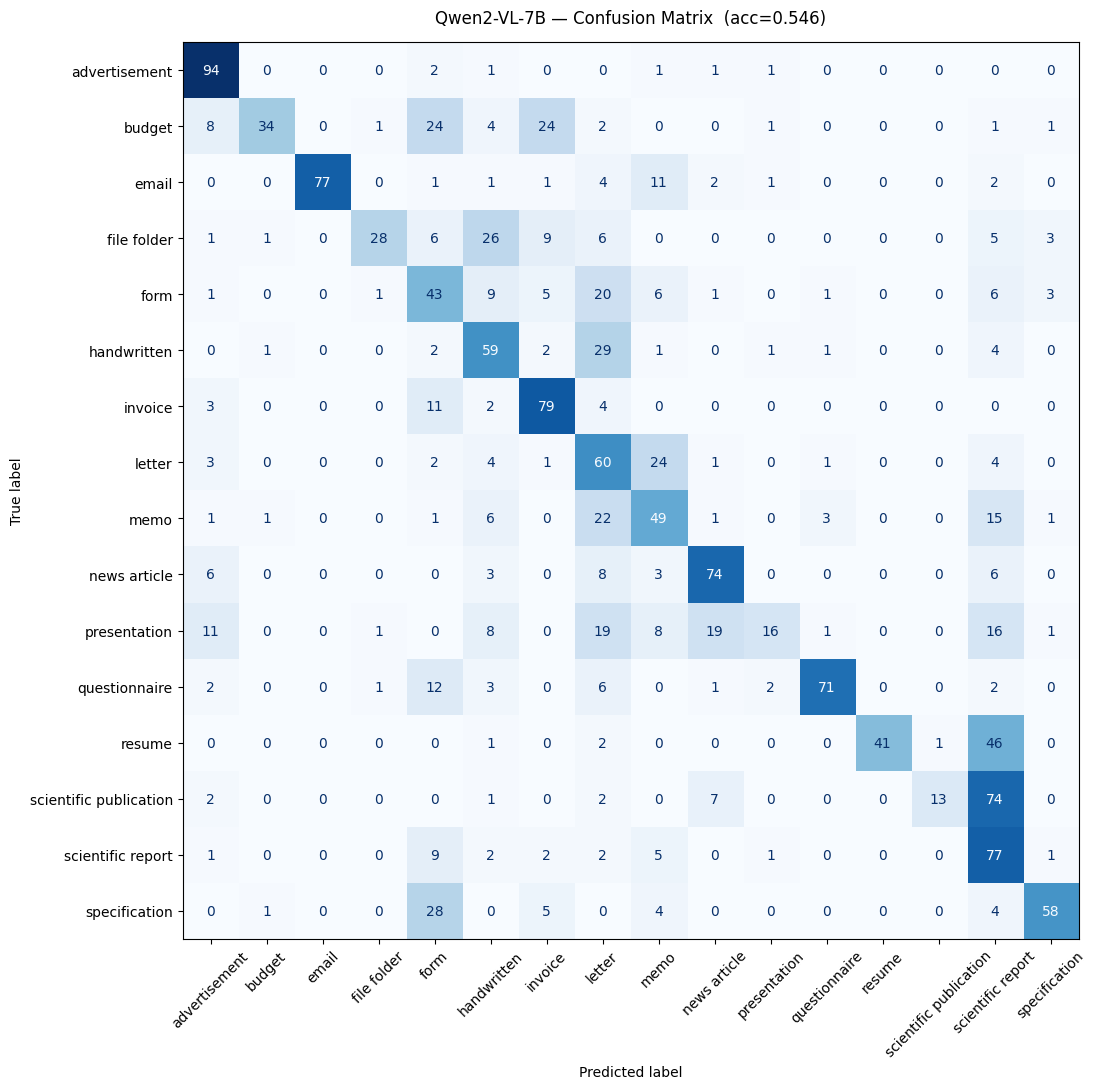

Saved → /kaggle/working/outputs/cm_qwen2-vl-7b.png
  💾 Checkpoint salvato → /kaggle/working/outputs/checkpoint.pkl  (modelli: ['Qwen2-VL-7B'])
Memory freed.


In [10]:
if "Qwen2-VL-7B" in RESULTS:
    print("⏭️  Qwen2-VL-7B already evaluated — skipping.")
else:
    import gc, torch
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
    from qwen_vl_utils import process_vision_info
    from tqdm.notebook import tqdm

    # Libera memoria prima di caricare
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM libera: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

    bnb4 = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
    qwen  = Qwen2VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2-VL-7B-Instruct",
        quantization_config=bnb4,
        device_map="auto",
    )
    qproc = AutoProcessor.from_pretrained(
        "Qwen/Qwen2-VL-7B-Instruct",
        min_pixels=256*28*28,
        max_pixels=512*28*28,
    )
    qwen.eval()
    print("Qwen2-VL-7B loaded.")

    QWEN_PROMPT = (
        "You are an expert document classifier.\n"
        "Examine this scanned document carefully, paying attention to "
        "layout, text structure, headers, and visual elements.\n\n"
        "Classify it into exactly one of these categories:\n"
        "advertisement, budget, email, file folder, form, handwritten, "
        "invoice, letter, memo, news article, presentation, questionnaire, "
        "resume, scientific publication, scientific report, specification\n\n"
        "Rules:\n"
        "- Reply with ONLY the category name, nothing else.\n"
        "- No punctuation, no explanation, no extra words.\n"
        "- If unsure between two categories, pick the most specific one.\n"
        "Category:"
    )

    def qwen_classify(img, model, processor, prompt):
        messages = [{"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": prompt},
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, videos=video_inputs,
            padding=True, return_tensors="pt"
        ).to(model.device)
        with torch.no_grad():
            ids = model.generate(**inputs, max_new_tokens=5, do_sample=False)
        return processor.decode(
            ids[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True
        ).strip()

    qwen_preds     = []
    failed_indices = []

    for i, ex in enumerate(tqdm(all_examples_meta, desc="Qwen2-VL-7B")):
        img = resize_img(to_pil(ex["image"]), max_size=512)
        answer = qwen_classify(img, qwen, qproc, QWEN_PROMPT)
        pred   = parse_class(answer)
        if pred < 0:
            failed_indices.append(i)
        qwen_preds.append(pred)
        del img
        if (i + 1) % 50 == 0:
            gc.collect()
            torch.cuda.empty_cache()

    if failed_indices:
        print(f"⚠️  Parse fallito: {len(failed_indices)}/{len(all_examples_meta)}")

    print("Done.")
    evaluate("Qwen2-VL-7B", true_labels, qwen_preds, cmap="Blues")
    save_checkpoint()
    free_memory(qwen, qproc)

---
## Model 2 — Qwen2.5-VL-3B (Alibaba)
Compact version of Qwen2.5-VL — good balance between performance and VRAM usage.
Caricato in 4-bit quantization.

VRAM libera: 13.50 GB


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2.5-VL-3B loaded.


Qwen2.5-VL-3B:   0%|          | 0/1600 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


⚠️  Parse fallito: 2/1600
Done.
  ⚠ Unparsed preds: 2/1600 (0.1%)

───────────────────────────────────────────────────────
  Qwen2.5-VL-3B
───────────────────────────────────────────────────────
  Overall Accuracy : 0.541
  Macro F1         : 0.501
  Invoice F1       : 0.604

                        precision    recall  f1-score   support

         advertisement      0.876     0.850     0.863       100
                budget      0.947     0.180     0.303       100
                 email      1.000     0.300     0.462       100
           file folder      0.833     0.200     0.323       100
                  form      0.337     0.590     0.429       100
           handwritten      0.696     0.320     0.438       100
               invoice      0.571     0.640     0.604       100
                letter      0.447     0.510     0.477       100
                  memo      0.304     0.830     0.445       100
          news article      0.851     0.576     0.687        99
          presenta

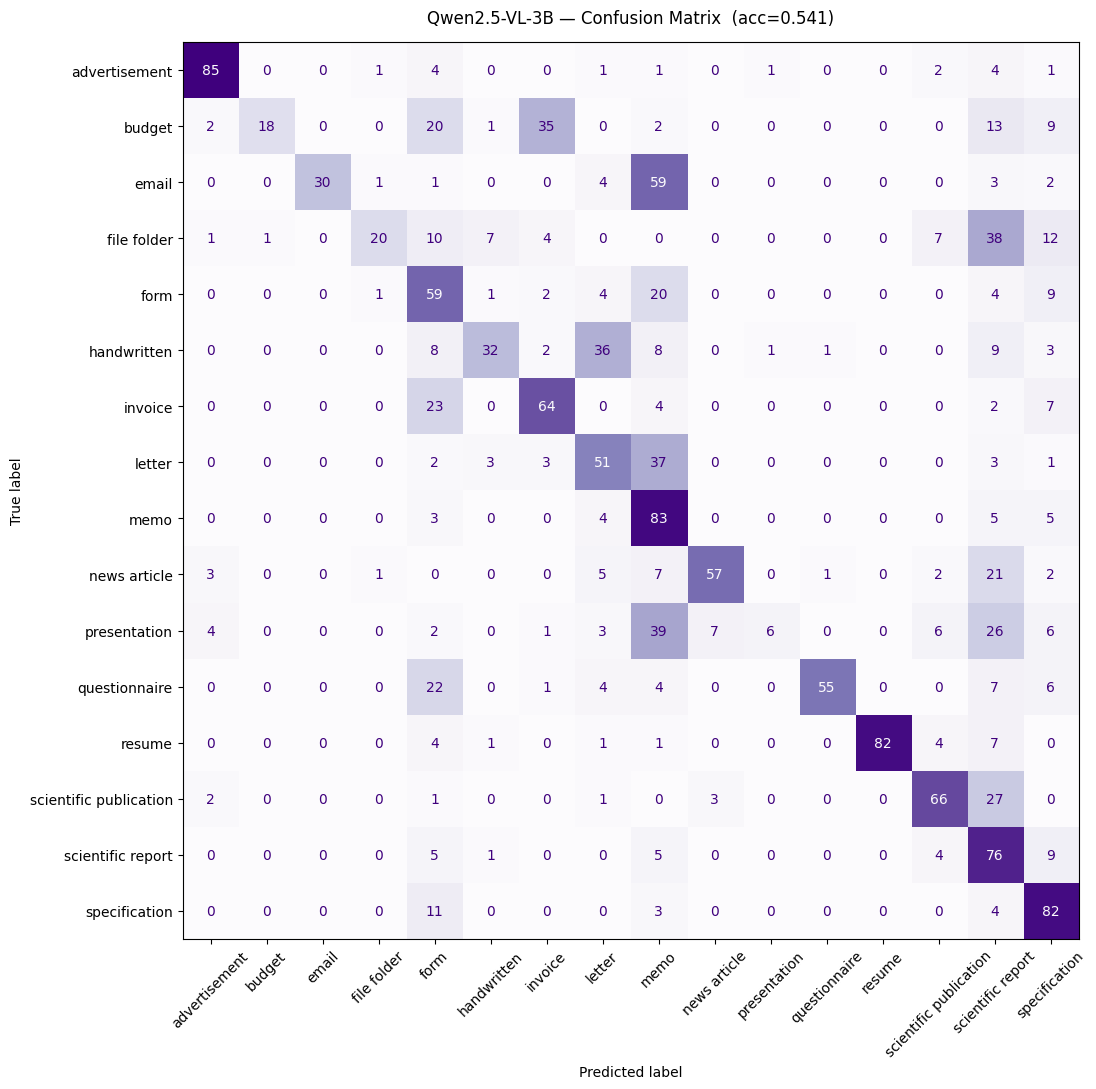

Saved → /kaggle/working/outputs/cm_qwen2.5-vl-3b.png
  💾 Checkpoint salvato → /kaggle/working/outputs/checkpoint.pkl  (modelli: ['Qwen2-VL-7B', 'Qwen2.5-VL-3B'])
Memory freed.


In [11]:
if "Qwen2.5-VL-3B" in RESULTS:
    print("⏭️  Qwen2.5-VL-3B already evaluated — skipping.")
else:
    import gc, torch
    from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
    from qwen_vl_utils import process_vision_info
    from tqdm.notebook import tqdm

    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM libera: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

    bnb4 = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
    qwen25  = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2.5-VL-3B-Instruct",
        quantization_config=bnb4,
        device_map="auto",
    )
    qproc25 = AutoProcessor.from_pretrained(
        "Qwen/Qwen2.5-VL-3B-Instruct",
        min_pixels=256*28*28,
        max_pixels=512*28*28,
    )
    qwen25.eval()
    print("Qwen2.5-VL-3B loaded.")

    QWEN25_PROMPT = (
        "You are an expert document classifier.\n"
        "Examine this scanned document carefully, paying attention to "
        "layout, text structure, headers, and visual elements.\n\n"
        "Classify it into exactly one of these categories:\n"
        "advertisement, budget, email, file folder, form, handwritten, "
        "invoice, letter, memo, news article, presentation, questionnaire, "
        "resume, scientific publication, scientific report, specification\n\n"
        "Rules:\n"
        "- Reply with ONLY the category name, nothing else.\n"
        "- No punctuation, no explanation, no extra words.\n"
        "- If unsure between two categories, pick the most specific one.\n"
        "Category:"
    )

    def qwen25_classify(img, model, processor, prompt):
        messages = [{"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": prompt},
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, videos=video_inputs,
            padding=True, return_tensors="pt"
        ).to(model.device)
        with torch.no_grad():
            ids = model.generate(**inputs, max_new_tokens=5, do_sample=False)
        return processor.decode(
            ids[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True
        ).strip()

    qwen25_preds   = []
    failed_indices = []

    for i, ex in enumerate(tqdm(all_examples_meta, desc="Qwen2.5-VL-3B")):
        img = resize_img(to_pil(ex["image"]), max_size=512)
        answer = qwen25_classify(img, qwen25, qproc25, QWEN25_PROMPT)
        pred   = parse_class(answer)
        if pred < 0:
            failed_indices.append(i)
        qwen25_preds.append(pred)
        del img
        if (i + 1) % 50 == 0:
            gc.collect()
            torch.cuda.empty_cache()

    if failed_indices:
        print(f"⚠️  Parse fallito: {len(failed_indices)}/{len(all_examples_meta)}")

    print("Done.")
    evaluate("Qwen2.5-VL-3B", true_labels, qwen25_preds, cmap="Purples")
    save_checkpoint()
    free_memory(qwen25, qproc25)

---
## Model 3 — CLIP ViT-B/32 (OpenAI)
Contrastive baseline. Computes cosine similarity between image and text embeddings.

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.
  1600/1600
Done.

───────────────────────────────────────────────────────
  CLIP ViT-B/32
───────────────────────────────────────────────────────
  Overall Accuracy : 0.287
  Macro F1         : 0.263
  Invoice F1       : 0.123

                        precision    recall  f1-score   support

         advertisement      0.938     0.150     0.259       100
                budget      0.556     0.150     0.236       100
                 email      0.947     0.180     0.303       100
           file folder      0.295     0.520     0.377       100
                  form      0.121     0.570     0.200       100
           handwritten      0.900     0.360     0.514       100
               invoice      0.267     0.080     0.123       100
                letter      0.171     0.520     0.257       100
                  memo      0.278     0.580     0.375       100
          news article      0.456     0.730     0.562       100
          presentation      0.000     0.000     0.000

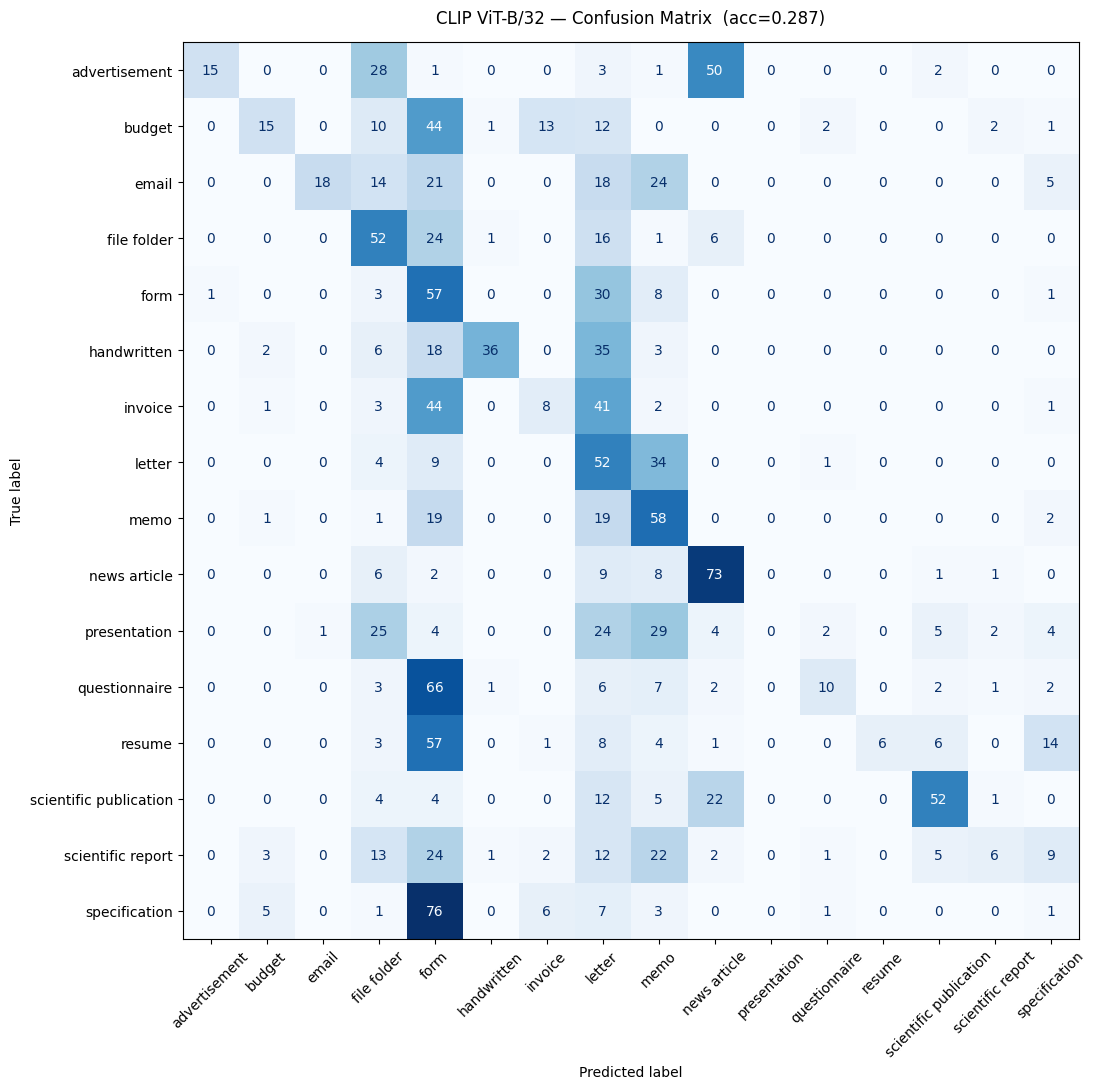

Saved → /kaggle/working/outputs/cm_clip_vit-b_32.png
  💾 Checkpoint salvato → /kaggle/working/outputs/checkpoint.pkl  (modelli: ['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32'])
Memory freed.


In [12]:
if "CLIP ViT-B/32" in RESULTS:
    print("⏭️  CLIP ViT-B/32 already evaluated — skipping.")
else:
    import gc, torch
    from transformers import CLIPProcessor, CLIPModel

    gc.collect()
    torch.cuda.empty_cache()

    # CLIP uses little VRAM — load images in batches from the metadata list
    clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
    proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip.eval()
    print("CLIP loaded.")

    CLIP_PROMPTS = [
        "a printed advertisement or marketing flyer with large text",
        "a budget spreadsheet or financial planning document with numbers",
        "a printed email message with sender, recipient and subject line",
        "a file folder label or folder cover page with an index tab",
        "a scanned form with blank fields and checkboxes to fill in",
        "a handwritten document or handwritten note on paper",
        "a scanned invoice or bill with itemised charges, prices and a total amount due",
        "a scanned business letter with recipient address and signature",
        "an internal memo or office memorandum addressed to staff",
        "a newspaper article or news clipping with columns of text",
        "a presentation slide with large text, bullet points or visuals",
        "a questionnaire or survey form with numbered questions",
        "a resume or curriculum vitae listing work experience and education",
        "a scientific publication or academic paper with references",
        "a scientific report with charts, data tables and technical content",
        "a technical specification document with detailed requirements",
    ]

    BATCH = 16
    clip_preds = []

    for start in range(0, len(all_examples_meta), BATCH):
        batch_ex = all_examples_meta[start:start+BATCH]
        batch_imgs = [to_pil(ex["image"]) for ex in batch_ex]
        inputs = proc(text=CLIP_PROMPTS, images=batch_imgs, return_tensors="pt",
                      padding=True).to(DEVICE)
        with torch.no_grad():
            probs = clip(**inputs).logits_per_image.softmax(dim=-1)
        clip_preds.extend(probs.argmax(dim=-1).cpu().tolist())
        del batch_imgs
        print(f"  {min(start+BATCH, len(all_examples_meta))}/{len(all_examples_meta)}", end="\r")

    print("\nDone.")
    evaluate("CLIP ViT-B/32", true_labels, clip_preds, cmap="Blues")
    save_checkpoint()
    free_memory(clip, proc)

---
## Model 4 — SmolVLM-500M (HuggingFace)
Lightweight instruction-tuned VLM. No HuggingFace login required.

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

SmolVLM-500M loaded.
  1600/1600
Done.
  ⚠ Unparsed preds: 71/1600 (4.4%)

───────────────────────────────────────────────────────
  SmolVLM-500M
───────────────────────────────────────────────────────
  Overall Accuracy : 0.266
  Macro F1         : 0.227
  Invoice F1       : 0.381

                        precision    recall  f1-score   support

         advertisement      0.214     0.031     0.055        96
                budget      0.168     0.840     0.280       100
                 email      0.461     0.423     0.441        97
           file folder      0.086     0.168     0.113        95
                  form      0.476     0.208     0.290        96
           handwritten      0.472     0.179     0.260        95
               invoice      0.266     0.677     0.382        99
                letter      0.250     0.010     0.019        99
                  memo      0.625     0.306     0.411        98
          news article      0.500     0.042     0.077        96
          p

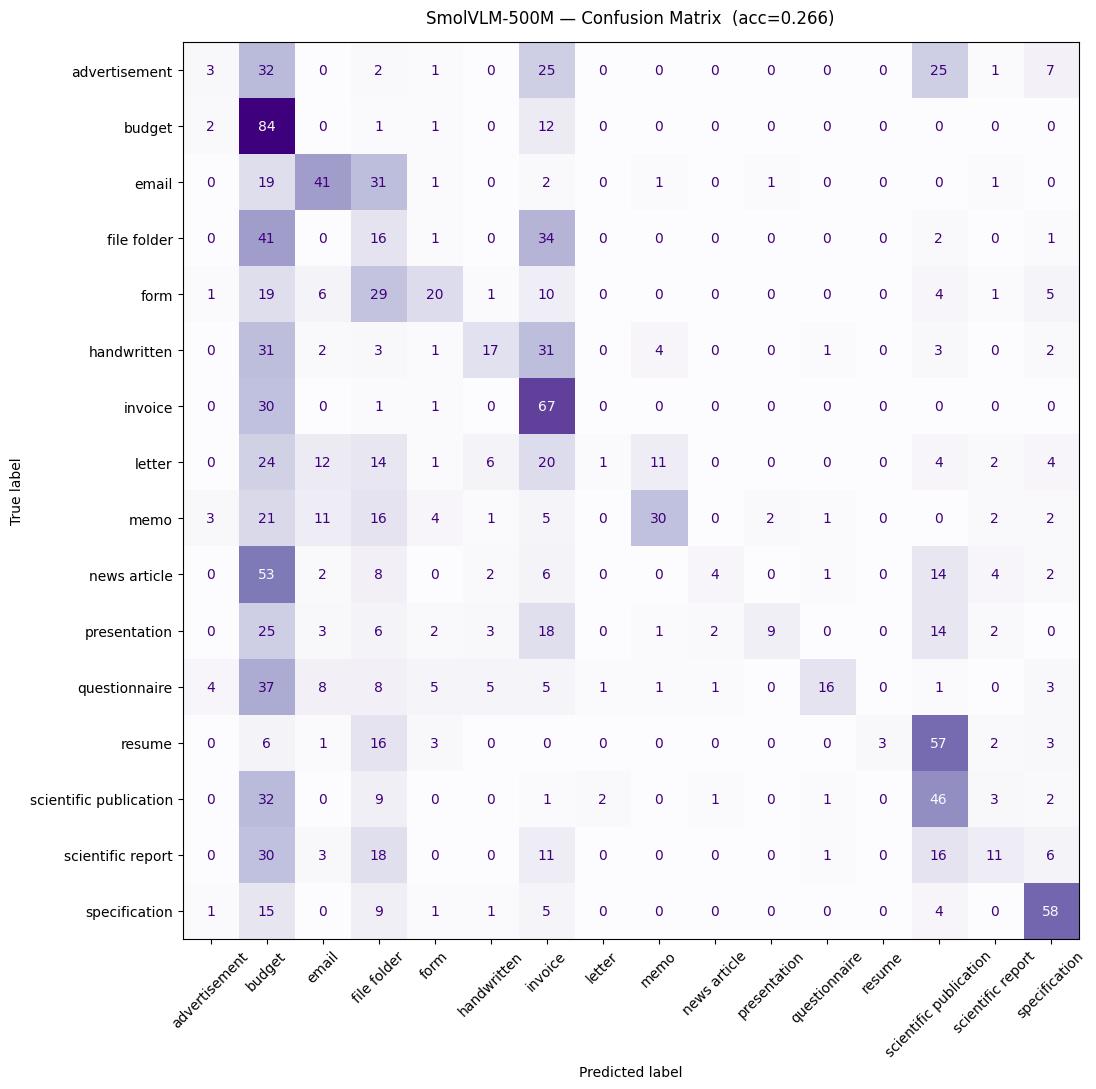

Saved → /kaggle/working/outputs/cm_smolvlm-500m.png
  💾 Checkpoint salvato → /kaggle/working/outputs/checkpoint.pkl  (modelli: ['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32', 'SmolVLM-500M'])
Memory freed.


In [13]:
if "SmolVLM-500M" in RESULTS:
    print("⏭️  SmolVLM-500M already evaluated — skipping.")
else:
    import gc, torch
    from transformers import AutoProcessor, Idefics3ForConditionalGeneration

    gc.collect()
    torch.cuda.empty_cache()

    smol = Idefics3ForConditionalGeneration.from_pretrained(
        "HuggingFaceTB/SmolVLM-500M-Instruct",
        torch_dtype=torch.float16,
        trust_remote_code=True,
        device_map='auto'
    )
    sproc = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")
    smol.eval()
    print("SmolVLM-500M loaded.")

    SMOL_PROMPT = (
        "Look at this scanned document image carefully.\n"
        "Choose the single best category from the list below.\n\n"
        "advertisement\nbudget\nemail\nfile folder\nform\nhandwritten\n"
        "invoice\nletter\nmemo\nnews article\npresentation\nquestionnaire\n"
        "resume\nscientific publication\nscientific report\nspecification\n\n"
        "Reply with ONLY the category name. Do not explain. Do not add punctuation.\n"
        "Category:"
    )

    smol_preds = []
    for i, ex in enumerate(all_examples_meta):
        img = to_pil(ex["image"])
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": SMOL_PROMPT}
        ]}]
        prompt = sproc.apply_chat_template(messages, add_generation_prompt=True)
        inputs = sproc(text=prompt, images=[img.convert("RGB")], return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            ids = smol.generate(**inputs, max_new_tokens=15, do_sample=False)
        input_len = inputs["input_ids"].shape[-1]
        answer = sproc.decode(ids[0][input_len:], skip_special_tokens=True).strip()
        smol_preds.append(parse_class(answer))
        del img
        if (i + 1) % 50 == 0:
            gc.collect()
            torch.cuda.empty_cache()
            print(f"  {i+1}/{len(all_examples_meta)}", end="\r")

    print("\nDone.")
    evaluate("SmolVLM-500M", true_labels, smol_preds, cmap="Purples")
    save_checkpoint()
    free_memory(smol, sproc)

---
## Model 5 — PaliGemma2-3B (Google)
Compact vision-language model by Google. Requires HuggingFace login (gated model).

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

...

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

PaliGemma2-3B loaded.
  1600/1600
Done.
  ⚠ Unparsed preds: 43/1600 (2.7%)

───────────────────────────────────────────────────────
  PaliGemma2-3B
───────────────────────────────────────────────────────
  Overall Accuracy : 0.418
  Macro F1         : 0.369
  Invoice F1       : 0.241

                        precision    recall  f1-score   support

         advertisement      0.760     0.760     0.760       100
                budget      1.000     0.048     0.092        83
                 email      0.562     0.919     0.697        99
           file folder      0.448     0.640     0.527       100
                  form      0.278     0.204     0.235        98
           handwritten      0.618     0.810     0.701       100
               invoice      0.875     0.143     0.246        98
                letter      0.333     0.010     0.020        97
                  memo      0.000     0.000     0.000        94
          news article      0.711     0.690     0.701       100
         

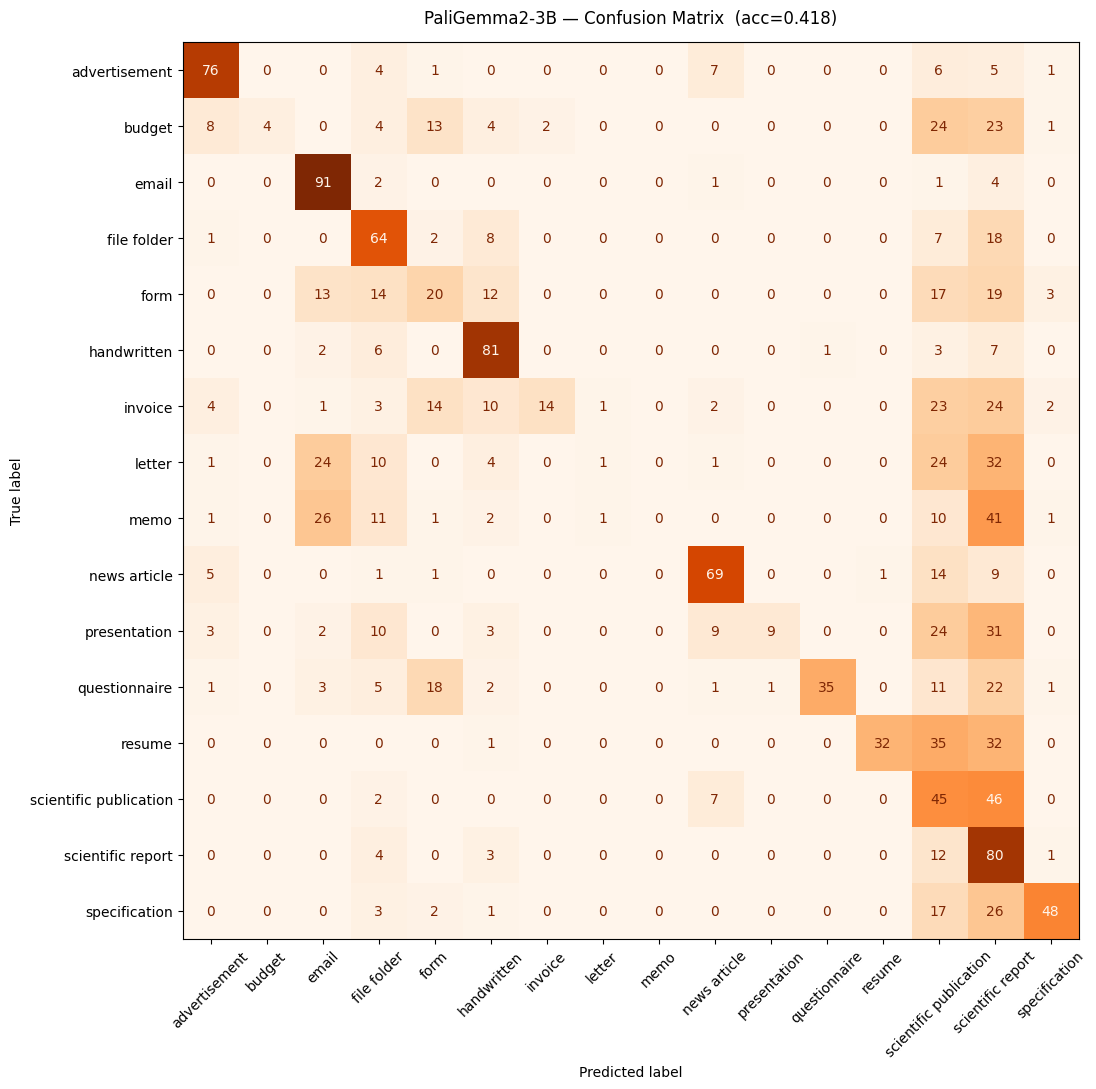

Saved → /kaggle/working/outputs/cm_paligemma2-3b.png
  💾 Checkpoint salvato → /kaggle/working/outputs/checkpoint.pkl  (modelli: ['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32', 'SmolVLM-500M', 'PaliGemma2-3B'])
Memory freed.


In [14]:
if "PaliGemma2-3B" in RESULTS:
    print("⏭️  PaliGemma2-3B already evaluated — skipping.")
else:
    import gc, torch
    from transformers import PaliGemmaForConditionalGeneration, AutoProcessor

    gc.collect()
    torch.cuda.empty_cache()

    pali  = PaliGemmaForConditionalGeneration.from_pretrained(
        "google/paligemma2-3b-mix-448",
        torch_dtype=torch.bfloat16,
        token=HF_TOKEN,
        device_map='auto'
    )
    pproc = AutoProcessor.from_pretrained("google/paligemma2-3b-mix-448", token=HF_TOKEN)
    pali.eval()
    print("PaliGemma2-3B loaded.")

    PALI_PROMPT = (
        "<image>Classify this scanned document. Choose one from: "
        + ", ".join(CLASS_NAMES) + ". Answer with only the class name."
    )

    pali_preds = []
    for i, ex in enumerate(all_examples_meta):
        img = to_pil(ex["image"])
        inputs = pproc(text=PALI_PROMPT, images=img, return_tensors="pt").to(DEVICE)
        input_len = inputs["input_ids"].shape[-1]
        with torch.inference_mode():
            ids    = pali.generate(**inputs, max_new_tokens=15, do_sample=False)
            answer = pproc.decode(ids[0][input_len:], skip_special_tokens=True)
        pali_preds.append(parse_class(answer))
        del img
        if (i + 1) % 50 == 0:
            gc.collect()
            torch.cuda.empty_cache()
            print(f"  {i+1}/{len(all_examples_meta)}", end="\r")

    print("\nDone.")
    evaluate("PaliGemma2-3B", true_labels, pali_preds, cmap="Oranges")
    save_checkpoint()
    free_memory(pali, pproc)

---
## Model 6 — DiT-large (Microsoft) ⚠️ Supervised
Document Image Transformer fine-tuned directly on RVL-CDIP.
**Note**: only supervised model — not zero-shot. See README for details.

preprocessor_config.json:   0%|          | 0.00/302 [00:00<?, ?B/s]

The image processor of type `BeitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/416 [00:00<?, ?it/s]

DiT-large loaded. GPU memory: 8.93 GB


model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

  [1600/1600]
Done.

───────────────────────────────────────────────────────
  DiT-large
───────────────────────────────────────────────────────
  Overall Accuracy : 0.929
  Macro F1         : 0.929
  Invoice F1       : 0.935

                        precision    recall  f1-score   support

         advertisement      0.931     0.940     0.935       100
                budget      0.895     0.940     0.917       100
                 email      1.000     1.000     1.000       100
           file folder      0.932     0.960     0.946       100
                  form      0.913     0.840     0.875       100
           handwritten      0.951     0.970     0.960       100
               invoice      0.939     0.930     0.935       100
                letter      0.933     0.970     0.951       100
                  memo      0.979     0.940     0.959       100
          news article      0.918     0.900     0.909       100
          presentation      0.825     0.850     0.837       100
    

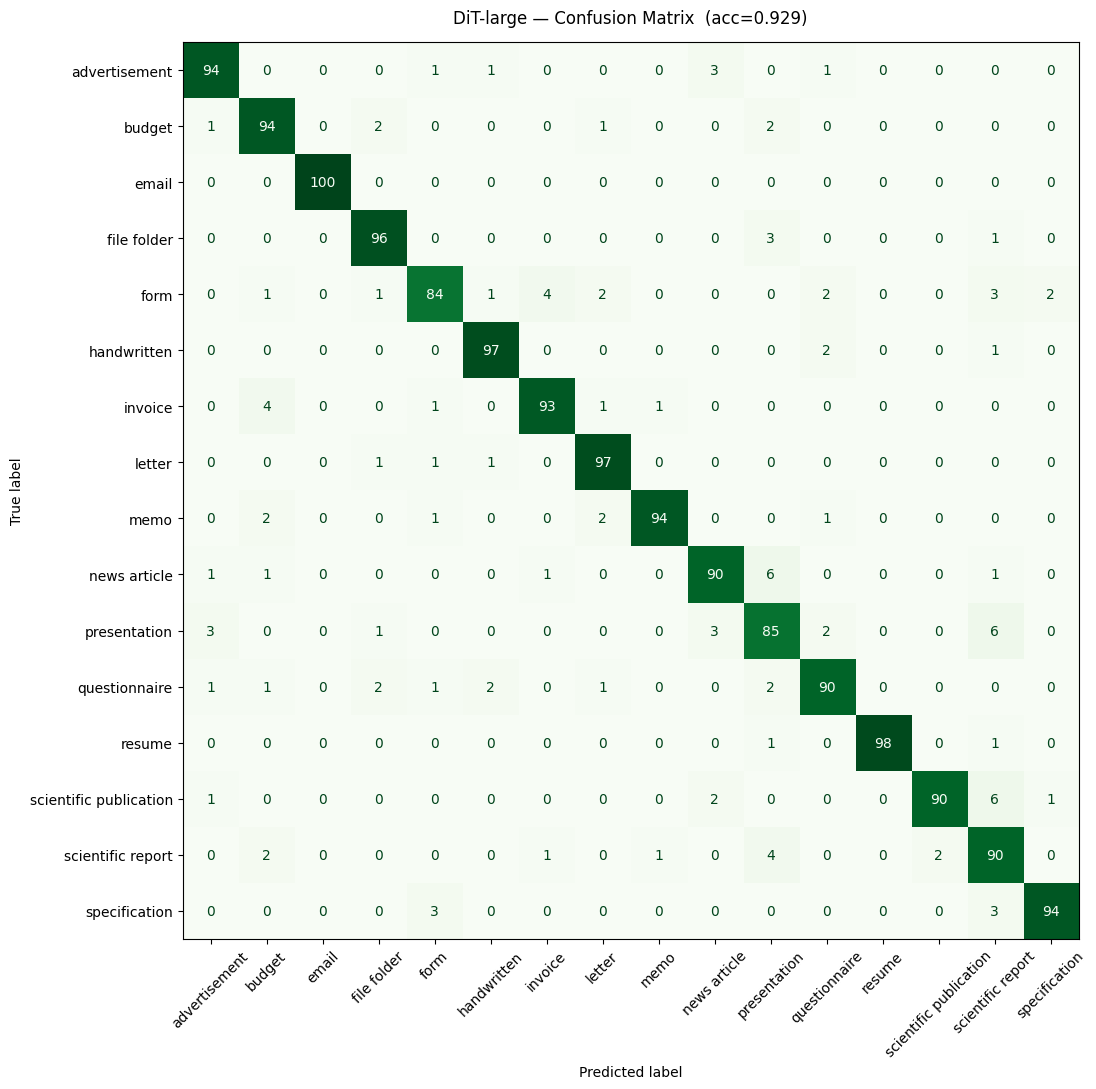

Saved → /kaggle/working/outputs/cm_dit-large.png
  💾 Checkpoint salvato → /kaggle/working/outputs/checkpoint.pkl  (modelli: ['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32', 'SmolVLM-500M', 'PaliGemma2-3B', 'DiT-large'])
Memory freed.


In [15]:
if "DiT-large" in RESULTS:
    print("⏭️  DiT-large already evaluated — skipping.")
else:
    import gc, torch
    from transformers import AutoImageProcessor, AutoModelForImageClassification

    gc.collect()
    torch.cuda.empty_cache()

    DIT_ID    = "microsoft/dit-large-finetuned-rvlcdip"
    dit_proc  = AutoImageProcessor.from_pretrained(DIT_ID)
    dit_model = AutoModelForImageClassification.from_pretrained(DIT_ID).to(DEVICE)
    dit_model.eval()
    print(f"DiT-large loaded. GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    def classify_dit(image):
        inputs = dit_proc(images=image.convert("RGB"), return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = dit_model(**inputs).logits
        pred_idx  = logits.argmax(-1).item()
        label_str = dit_model.config.id2label[pred_idx]
        return parse_class(label_str)

    dit_preds = []
    for i, ex in enumerate(all_examples_meta):
        img = to_pil(ex["image"])
        dit_preds.append(classify_dit(img))
        del img
        if (i + 1) % 50 == 0:
            gc.collect()
            print(f"  [{i+1}/{len(all_examples_meta)}]", end="\r")

    print("\nDone.")
    evaluate("DiT-large", true_labels, dit_preds, cmap="Greens")
    save_checkpoint()
    free_memory(dit_model, dit_proc)

## 4 — Final comparison

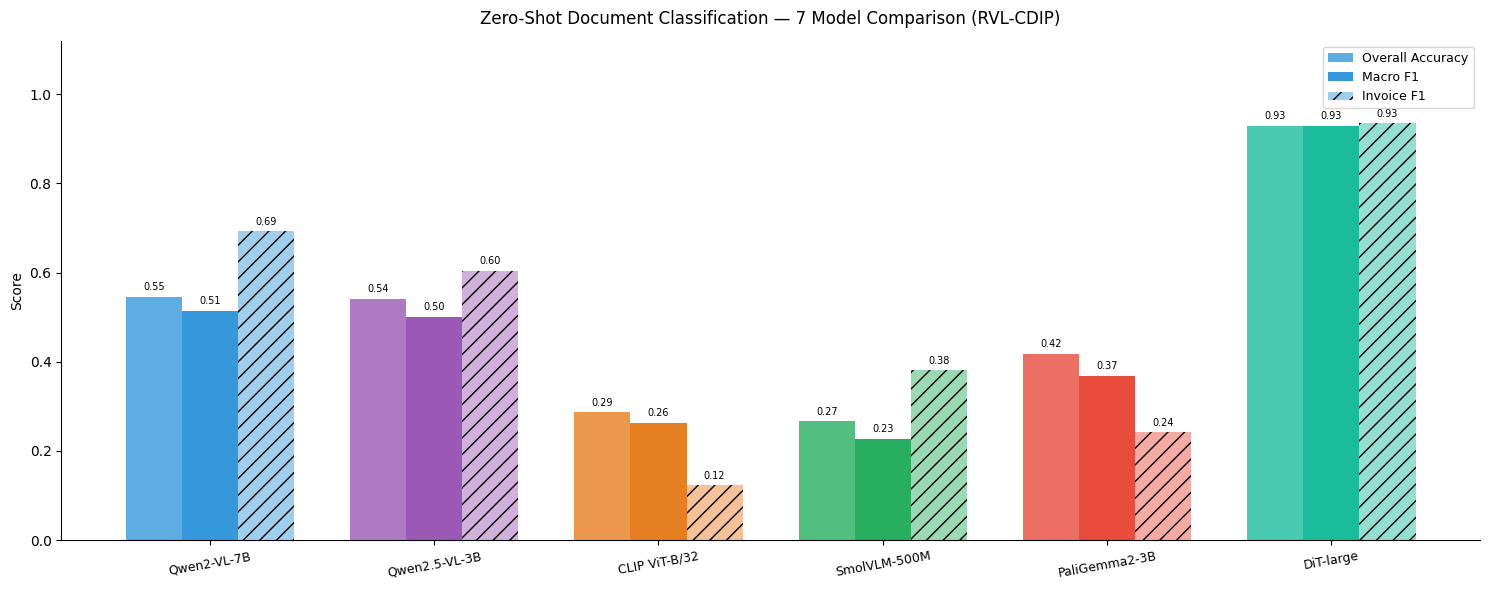

Saved → /kaggle/working/outputs/02_model_comparison.png

── Summary table ──────────────────────────────────────────
Model                       Accuracy   Macro F1   Invoice F1   Unparsed
──────────────────────────────────────────────────────────────────────
Qwen2-VL-7B                    0.546       0.514       0.693         30
Qwen2.5-VL-3B                  0.541       0.501       0.604          2
CLIP ViT-B/32                  0.287       0.263       0.123          0
SmolVLM-500M                   0.266       0.227       0.381         71
PaliGemma2-3B                  0.418       0.369       0.241         43
DiT-large                      0.929★      0.929       0.935★         0
  ★ = best in category


In [16]:
model_names = list(RESULTS.keys())
accs     = [RESULTS[m]["accuracy"]  for m in model_names]
f1_macro = [RESULTS[m]["f1_macro"]  for m in model_names]
inv_f1   = [RESULTS[m]["inv_f1"]    for m in model_names]

colours = ["#3498db", "#9b59b6", "#e67e22", "#27ae60", "#e74c3c", "#1abc9c", "#f39c12"]
x = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
b1 = ax.bar(x - w,   accs,     w, label="Overall Accuracy", color=[c+"cc" for c in colours[:len(model_names)]])
b2 = ax.bar(x,       f1_macro, w, label="Macro F1",         color=colours[:len(model_names)])
b3 = ax.bar(x + w,   inv_f1,   w, label="Invoice F1",       color=[c+"77" for c in colours[:len(model_names)]], hatch="//")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9, rotation=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Zero-Shot Document Classification — 7 Model Comparison (RVL-CDIP)", fontsize=12, pad=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

path = os.path.join(OUTPUT_DIR, "02_model_comparison.png")
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

print("\n── Summary table ──────────────────────────────────────────")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Invoice F1':>12} {'Unparsed':>10}")
print("─" * 70)
for m in model_names:
    r = RESULTS[m]
    best_acc = "★" if r["accuracy"] == max(accs)   else " "
    best_inv = "★" if r["inv_f1"]   == max(inv_f1) else " "
    print(f"{m:<25} {r['accuracy']:>10.3f}{best_acc} {r['f1_macro']:>10.3f}  {r['inv_f1']:>10.3f}{best_inv} {r['unparsed']:>9}")
print("  ★ = best in category")

## 5 — Save all results

In [17]:
results_path = os.path.join(OUTPUT_DIR, "02_classification_results.txt")
with open(results_path, "w") as f:
    f.write("Zero-Shot Document Classification — Results\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Dataset  : chainyo/rvl-cdip (test, shuffled)\n")
    f.write(f"Examples : {N_PER_CLASS}/class × {len(ALL_LABELS)} = {len(all_examples_meta)}\n")
    f.write(f"Device   : {DEVICE}\n\n")
    f.write(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Invoice F1':>12} {'Unparsed':>10}\n")
    f.write("─" * 70 + "\n")
    for m in model_names:
        r = RESULTS[m]
        f.write(f"{m:<25} {r['accuracy']:>10.3f} {r['f1_macro']:>10.3f}"
                f" {r['inv_f1']:>12.3f} {r['unparsed']:>10}\n")
    f.write("\n")
    for m in model_names:
        f.write(f"\n{'═'*55}\n{m}\n{'═'*55}\n")
        parsed_mask = [p >= 0 for p in RESULTS[m]['preds']]
        tl_p = [t for t, ok in zip(true_labels, parsed_mask) if ok]
        pl_p = [p for p, ok in zip(RESULTS[m]['preds'], parsed_mask) if ok]
        f.write(classification_report(tl_p, pl_p, target_names=CLASS_NAMES,
                                      labels=ALL_LABELS, digits=3, zero_division=0))

print(f"Results saved → {results_path}")
print("\n✅ Step 2 complete.")
print("   Next: 03_extraction.ipynb — extract fields from invoices.")

Results saved → /kaggle/working/outputs/02_classification_results.txt

✅ Step 2 complete.
   Next: 03_extraction.ipynb — extract fields from invoices.
